# Long-Tail Entity Analysis — Visualization Suite
### GLiNER (NER) + RefinED (Entity Linking) on Signal-1M

---
**Data:** `test/visualizations/refined_summary_table_percentages.csv`  
Each row = one GLiNER NER type. Columns = % of mentions assigned that EL type by RefinED.  
- **Unlinked** = RefinED returned no Wikipedia match at all  
- **NIL** = RefinED found a candidate but Wikipedia returned no usable type  
---

## 0 · Imports & Setup

In [76]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
import squarify
import os

# ── Global style ──────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["DejaVu Serif", "Georgia", "Times New Roman"],
    "font.size":          9,
    "axes.titlesize":     11,
    "axes.labelsize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "legend.fontsize":    8,
    "figure.dpi":         120,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.color":         "#e8e4de",
    "grid.linewidth":     0.55,
    "axes.axisbelow":     True,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.facecolor":  "white",
})

os.makedirs("figures", exist_ok=True)

# ── Palette ───────────────────────────────────────────────────────────────────
C_UNLINKED = "#c0392b"
C_NIL      = "#e67e22"
C_LINKED   = "#2d5a8e"
C_ACCENT   = "#e8c547"

EL_COLS    = ["PERSON","WORK_OF_ART","GPE","ORG","FAC","DATE",
              "LANGUAGE","CARDINAL","PRODUCT","EVENT",
              "PERCENT","TIME","ORDINAL","QUANTITY","MONEY"]
EL_COLORS  = [
    "#2d5a8e","#8b5cf6","#1a7a4a","#7a4a1a","#0ea5e9","#94a3b8",
    "#ec4899","#f59e0b","#6366f1","#10b981",
    "#64748b","#a78bfa","#f97316","#84cc16","#06b6d4",
]
EL_COLOR_MAP = dict(zip(EL_COLS, EL_COLORS))

# ── NEW NER Type Categories ───────────────────────────────────────────────────
ONTONOTE = {
    "person", "organization", "location", "gpe", "facility", 
    "product", "event", "work_of_art", "law", "language", "norp"
}

NUMERIC = {
    "date", "time", "percent", "money", "quantity", "ordinal", "cardinal"
}

EXTENSION_TYPE = {
    "political_party", "nationality", "ethnic_group", "religion", 
    "title", "award", "disease", "chemical", "weapon", "vehicle", 
    "brand", "currency"
}

def ner_category(t):
    if t in ONTONOTE: return "OntoNotes"
    if t in EXTENSION_TYPE: return "Extension Type"
    if t in NUMERIC: return "Numeric"
    return "Other"

# Update colors to match the new category names
CAT_COLORS = {
    "OntoNotes": "#1D3557",       # Navy Blue
    "Extension Type": "#E63946",  # Crimson Red
    "Numeric": "#2A9D8F",         # Deep Teal
    "Other": "#A8DADC"            # Light Blue-Grey
}

print("✓ Setup complete")

✓ Setup complete


## 1 · Load Data

In [77]:
CSV = "refined_summary_table_percentages.csv"
df  = pd.read_csv(CSV)

df["ner_type"] = df["ner_type"].str.lower().str.strip()

# Derived columns
df["Linked"]       = 100 - df["Unlinked"] - df["NIL"]   # % with a real EL type
df["category"]     = df["ner_type"].map(ner_category)
df["linked_count"] = (df["Linked"]   / 100 * df["Total"]).round().astype(int)
df["nil_count"]    = (df["NIL"]      / 100 * df["Total"]).round().astype(int)
df["unlinked_count"]=(df["Unlinked"] / 100 * df["Total"]).round().astype(int)

# Optional display step if running in Jupyter/Colab
try:
    display(df[["ner_type","Total","Linked","NIL","Unlinked","category"]].set_index("ner_type"))
except NameError:
    print(df[["ner_type","Total","Linked","NIL","Unlinked","category"]].set_index("ner_type").head())

,Total,Linked,NIL,Unlinked,category
ner_type,,,,,
person,1250956,25.64,3.33,71.03,OntoNotes
organization,958309,20.32,12.53,67.15,OntoNotes
location,452359,33.81,10.54,55.65,OntoNotes
product,433789,5.75,18.42,75.83,OntoNotes
quantity,331327,0.27,2.33,97.40,Numeric
event,277258,7.46,12.82,79.72,OntoNotes
title,130259,18.31,15.11,66.58,Extension Type
facility,117631,12.79,14.31,72.90,OntoNotes
money,99874,0.50,4.24,95.26,Numeric


---
## Plot 1 · Unlinked Rate per NER Type
*The headline figure — which types does RefinED struggle to link most?*

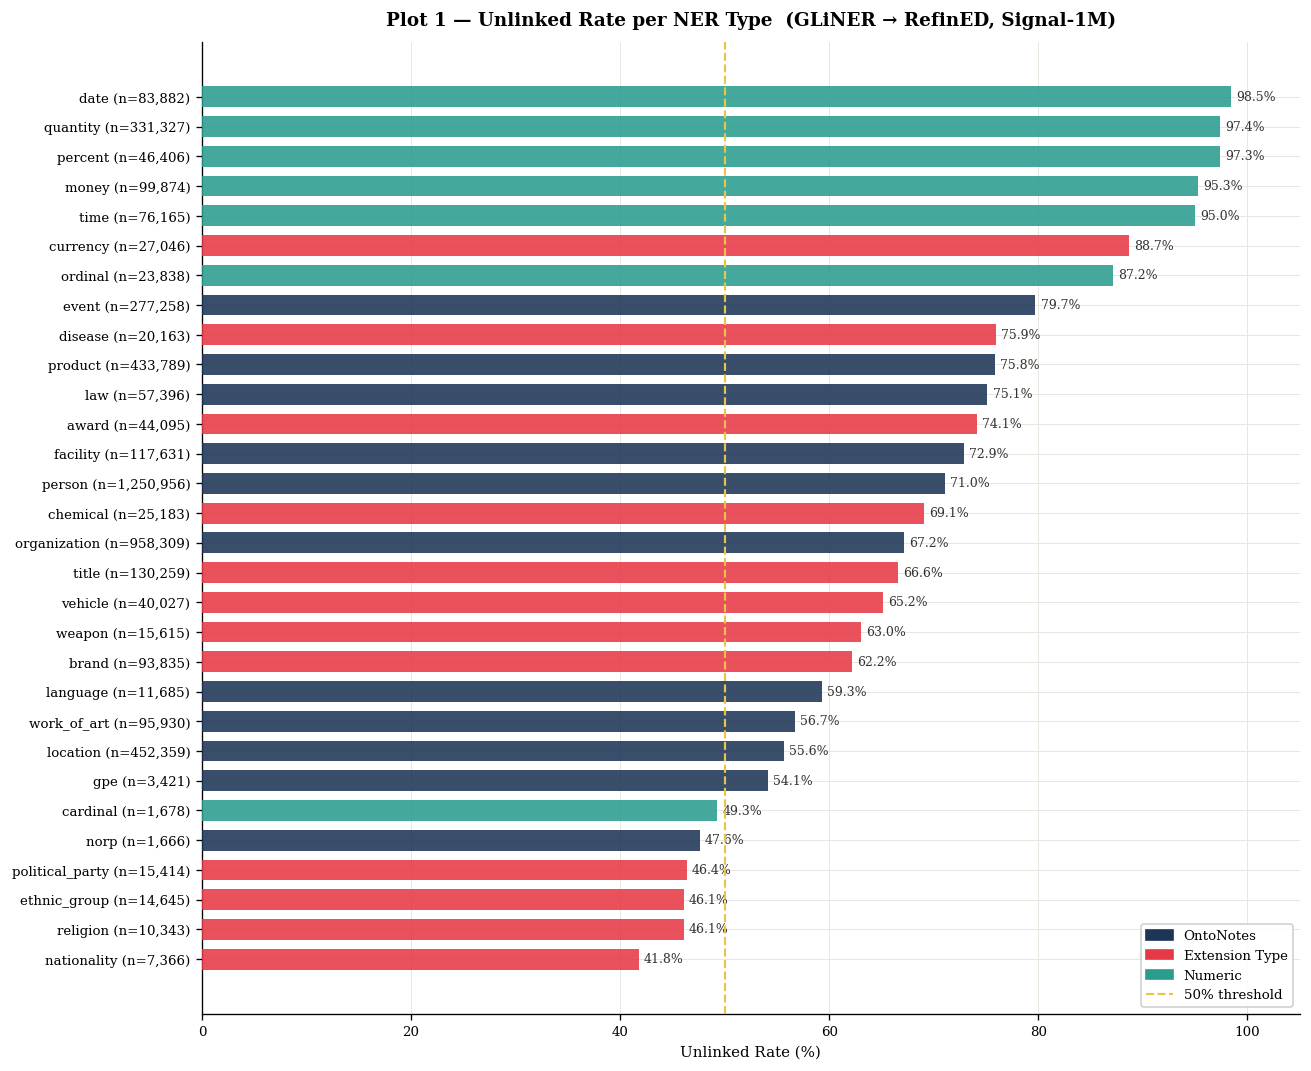

In [78]:
# ── Plotting ──────────────────────────────────────────────────────────────────
sdf = df.sort_values("Unlinked", ascending=True)

# Combine the NER type and its Total count into a single string for the Y-axis labels
sdf["ner_label"] = sdf.apply(lambda row: f"{row['ner_type']} (n={row['Total']:,})", axis=1)

# Generate color list based on mapped categories
colors = [CAT_COLORS.get(c, "#95a5a6") for c in sdf["category"]]

# Slightly widened the figure (from 10 to 11) to give the longer Y-axis labels more room
fig, ax = plt.subplots(figsize=(11, 9)) 

# Plot using the new 'ner_label' column for the Y-axis
bars = ax.barh(sdf["ner_label"], sdf["Unlinked"], color=colors, alpha=0.88,
               height=0.7, zorder=3)

# Annotate value (reverted back to just the percentage at the end of the bar)
for bar, val in zip(bars, sdf["Unlinked"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=7.5, color="#333")

ax.axvline(50, color=C_ACCENT, lw=1.3, ls="--", zorder=4, label="50% threshold")
ax.set_xlabel("Unlinked Rate (%)")
ax.set_xlim(0, 105) # Reverted back to 105 since the bar labels are short again
ax.set_title("Plot 1 — Unlinked Rate per NER Type  (GLiNER → RefinED, Signal-1M)",
             fontweight="bold", pad=10)

# Create custom legend using the new categories (excluding 'Other' if not present)
active_categories = [c for c in CAT_COLORS if c in sdf["category"].unique()]
legend_handles = [
    mpatches.Patch(color=CAT_COLORS[c], label=c) for c in active_categories
] + [plt.Line2D([0],[0], color=C_ACCENT, ls="--", lw=1.3, label="50% threshold")]

ax.legend(handles=legend_handles, loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.savefig("figures/plot1_unlinked_rate.pdf")
plt.show()

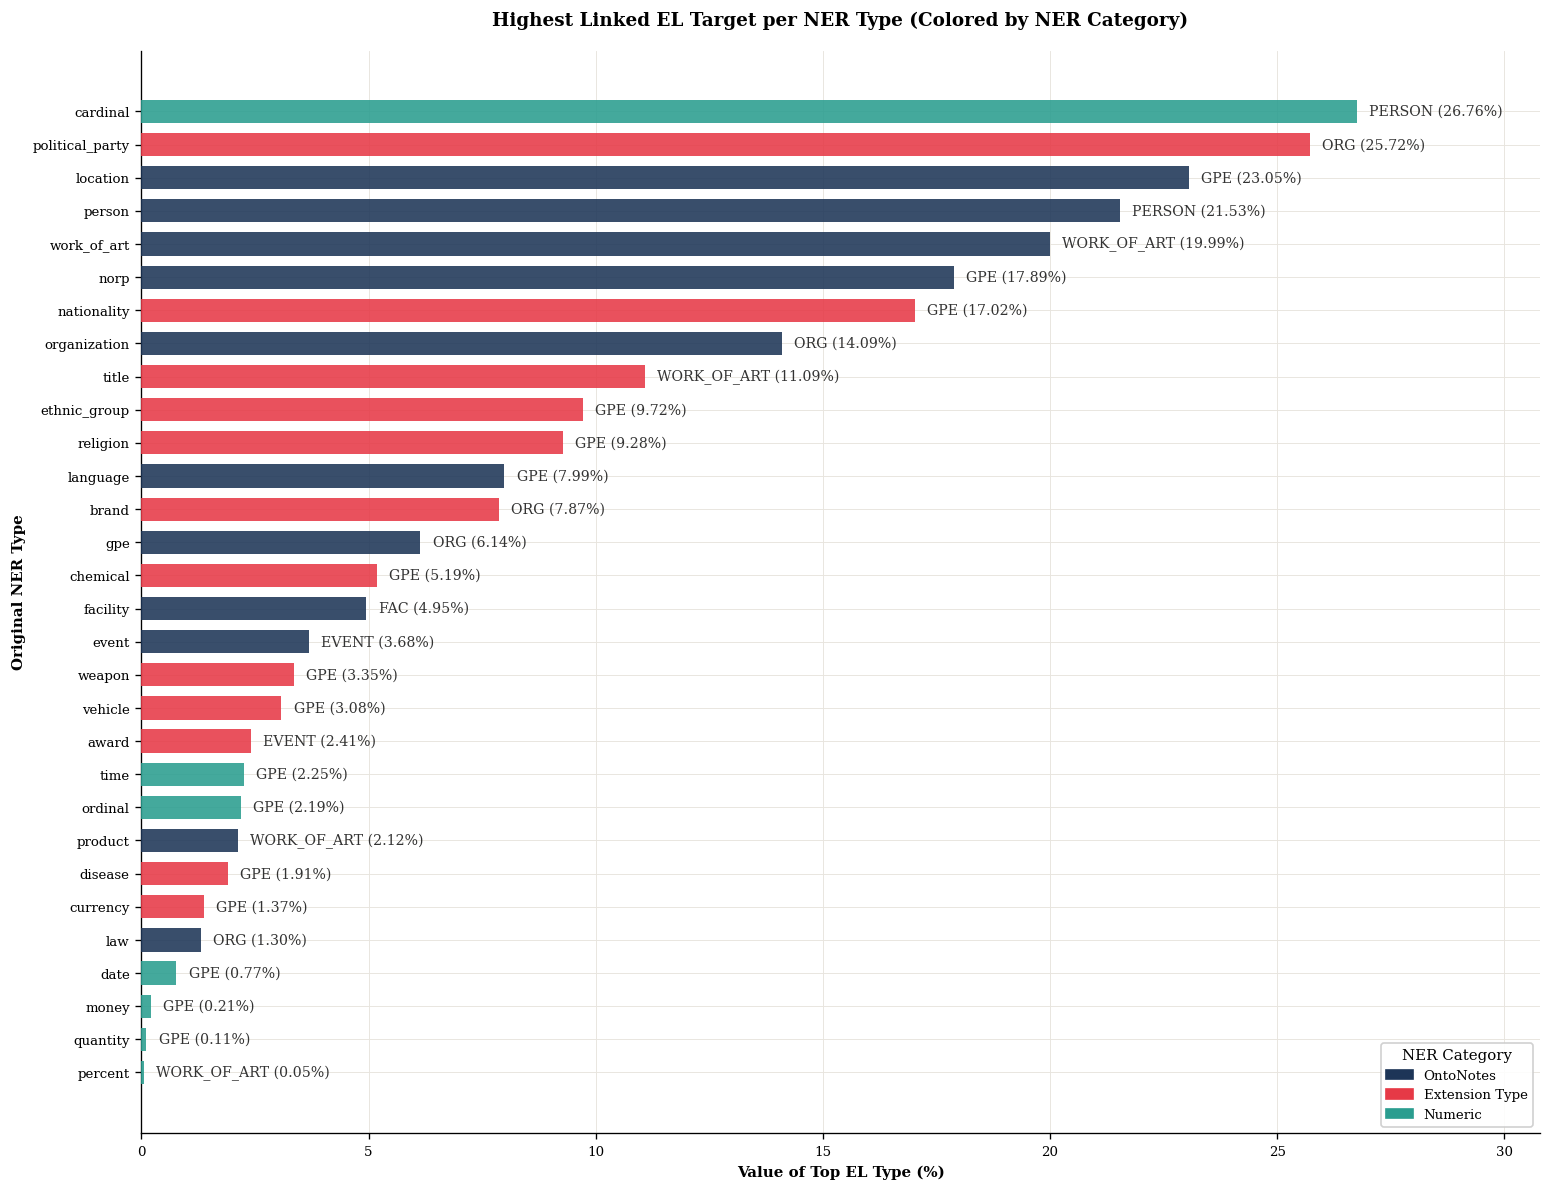

In [79]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ── Global style ──────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["DejaVu Serif", "Georgia", "Times New Roman"],
    "font.size":          9,
    "axes.titlesize":     11,
    "axes.labelsize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "legend.fontsize":    8,
    "figure.dpi":         120,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.color":         "#e8e4de",
    "grid.linewidth":     0.55,
    "axes.axisbelow":     True,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.facecolor":  "white",
})

os.makedirs("figures", exist_ok=True)

# ── NEW NER Type Categories & Colors ──────────────────────────────────────────
ONTONOTE = {
    "person", "organization", "location", "gpe", "facility", 
    "product", "event", "work_of_art", "law", "language", "norp"
}

NUMERIC = {
    "date", "time", "percent", "money", "quantity", "ordinal", "cardinal"
}

EXTENSION_TYPE = {
    "political_party", "nationality", "ethnic_group", "religion", 
    "title", "award", "disease", "chemical", "weapon", "vehicle", 
    "brand", "currency"
}

def ner_category(t):
    if t in ONTONOTE: return "OntoNotes"
    if t in EXTENSION_TYPE: return "Extension Type"
    if t in NUMERIC: return "Numeric"
    return "Other"

CAT_COLORS = {
    "OntoNotes": "#1D3557",       # Navy Blue
    "Extension Type": "#E63946",  # Crimson Red
    "Numeric": "#2A9D8F",         # Deep Teal
    "Other": "#A8DADC"            # Light Blue-Grey
}

EL_COLS = ["PERSON","WORK_OF_ART","GPE","ORG","FAC","DATE",
           "LANGUAGE","CARDINAL","PRODUCT","EVENT",
           "PERCENT","TIME","ORDINAL","QUANTITY","MONEY"]

# ── Data Processing ───────────────────────────────────────────────────────────
CSV = "refined_summary_table_percentages.csv"
df_2 = pd.read_csv(CSV)

# Clean ner_type column and map to categories
df_2["ner_type"] = df_2["ner_type"].str.lower().str.strip()
df_2["category"] = df_2["ner_type"].map(ner_category)

# Find the highest EL type and its exact value (percentage)
df_2["Top_EL_Type"] = df_2[EL_COLS].idxmax(axis=1)
df_2["Top_EL_Pct"] = df_2[EL_COLS].max(axis=1)

# Sort ascending by the percentage value so the largest bar is at the top
df_2 = df_2.sort_values(by="Top_EL_Pct", ascending=True)

# ── Plotting ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))

# Map the colors based on NER Category (instead of EL Type)
colors = [CAT_COLORS.get(c, "#95a5a6") for c in df_2["category"]]

# Plot using the EL Type Value
bars = ax.barh(df_2["ner_type"], df_2["Top_EL_Pct"], color=colors, alpha=0.88, height=0.7, zorder=3)

# Annotate the bars with the EL Type and its value
offset = df_2["Top_EL_Pct"].max() * 0.01

for bar, el_type, pct in zip(bars, df_2["Top_EL_Type"], df_2["Top_EL_Pct"]):
    ax.text(pct + offset, bar.get_y() + bar.get_height()/2,
            f"{el_type} ({pct:.2f}%)", va="center", fontsize=8.5, color="#333", fontweight="medium")

# Formatting
ax.set_xlabel("Value of Top EL Type (%)", fontweight="bold")
ax.set_ylabel("Original NER Type", fontweight="bold")
ax.set_xlim(0, df_2["Top_EL_Pct"].max() * 1.15)
ax.set_title("Highest Linked EL Target per NER Type (Colored by NER Category)", fontweight="bold", pad=15)

# Create custom legend using the new categories
active_categories = [c for c in CAT_COLORS if c in df_2["category"].unique()]
legend_handles = [mpatches.Patch(color=CAT_COLORS[c], label=c) for c in active_categories]

ax.legend(handles=legend_handles, title="NER Category", loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.savefig("figures/plot5_highest_el_value_categorized.pdf", dpi=300)
plt.show()

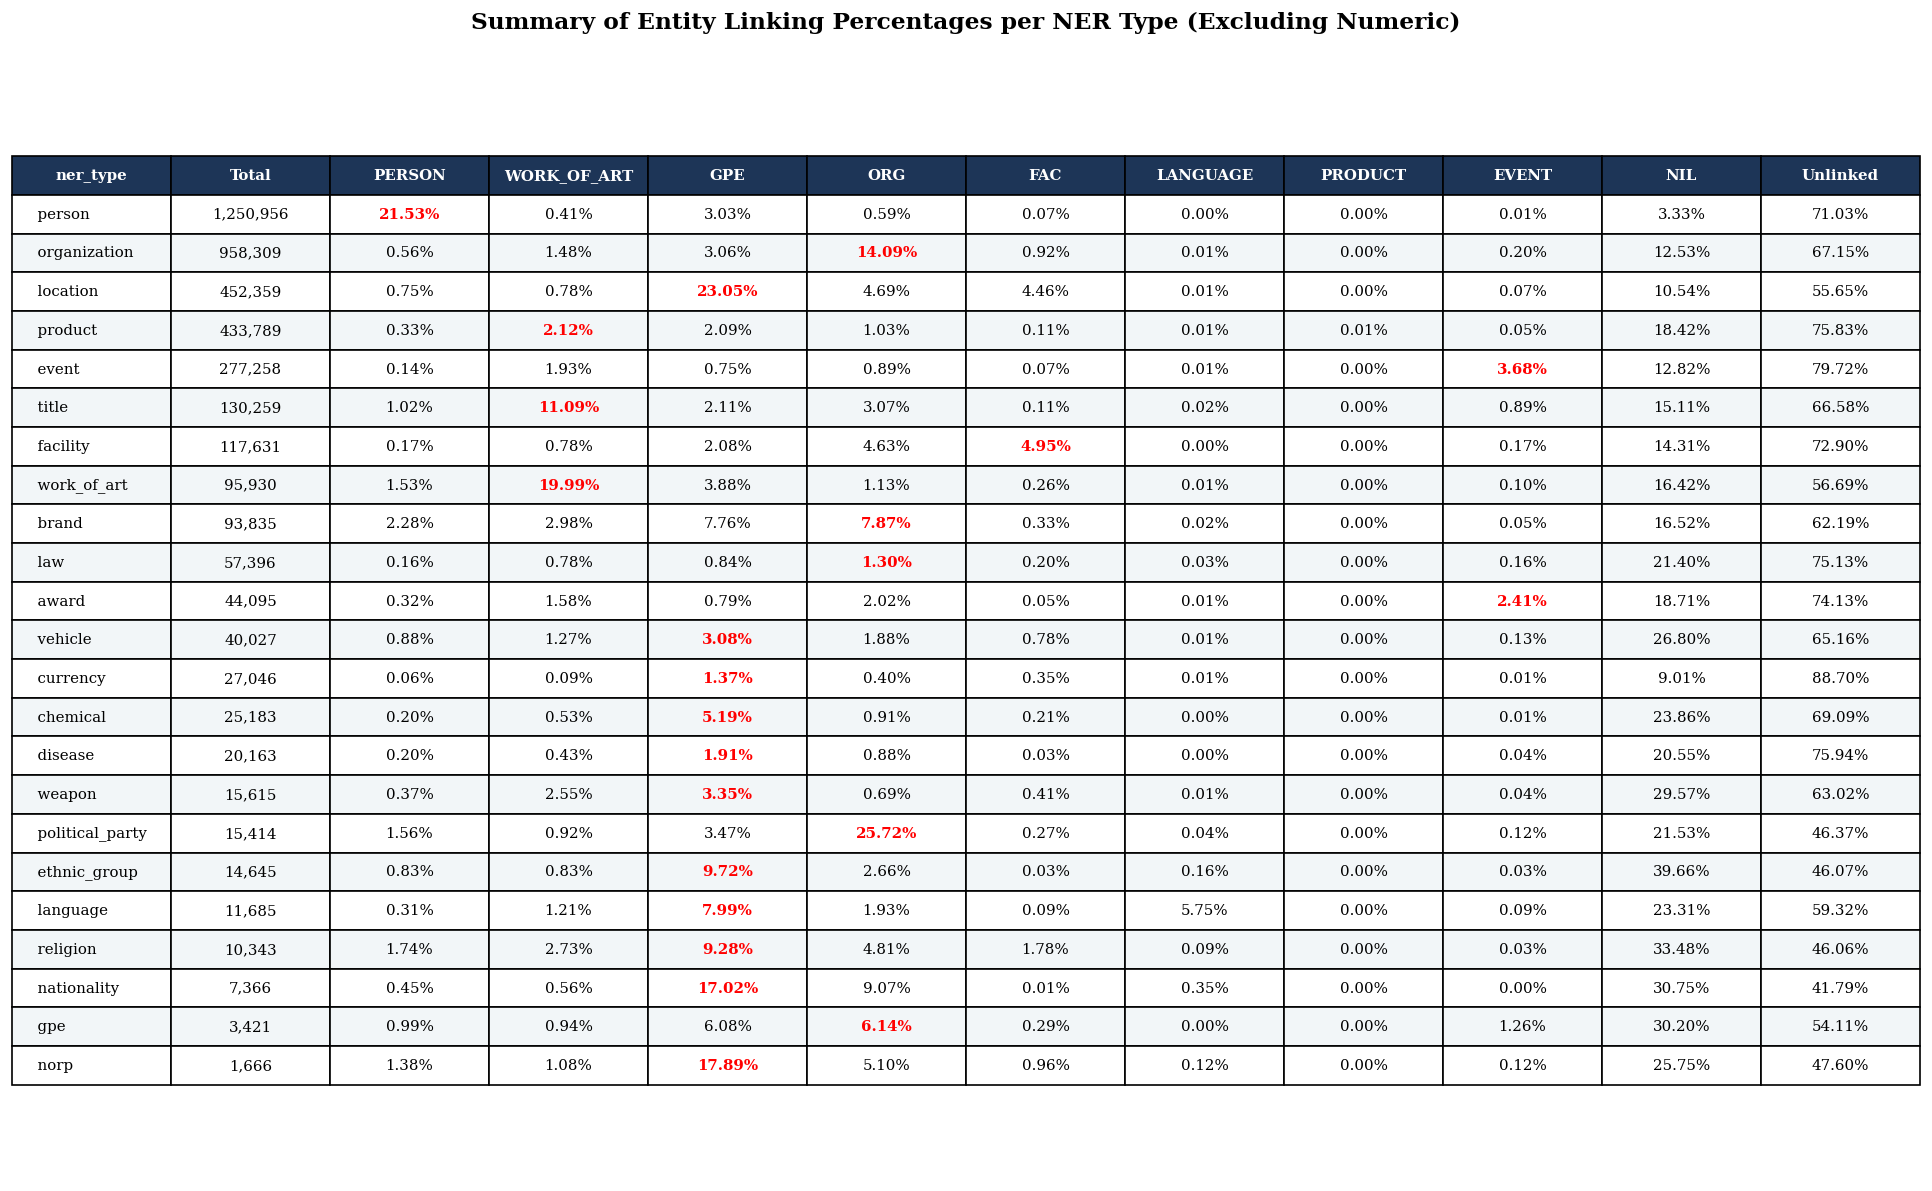

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Ensure the figures directory exists
os.makedirs("figures", exist_ok=True)

# Define categories
ONTONOTE = {
    "person", "organization", "location", "gpe", "facility", 
    "product", "event", "work_of_art", "law", "language", "norp"
}

NUMERIC = {
    "date", "time", "percent", "money", "quantity", "ordinal", "cardinal"
}

EXTENSION_TYPE = {
    "political_party", "nationality", "ethnic_group", "religion", 
    "title", "award", "disease", "chemical", "weapon", "vehicle", 
    "brand", "currency"
}

# Define the EL columns you want to hide
EL_COLS_TO_DROP = [
    "PERCENT", "TIME", "ORDINAL", "QUANTITY", "MONEY", "CARDINAL", "DATE"
]

# 1. Load the data
CSV = "refined_summary_table_percentages.csv"
df = pd.read_csv(CSV)

# Clean ner_type column to ensure accurate matching (lowercase and strip spaces)
df["ner_type_clean"] = df["ner_type"].str.lower().str.strip()

# Exclude rows where the cleaned ner_type is in the NUMERIC set
df = df[~df["ner_type_clean"].isin(NUMERIC)].copy()

# Drop the temporary column and the unwanted EL columns
df = df.drop(columns=["ner_type_clean"])
df = df.drop(columns=EL_COLS_TO_DROP, errors='ignore')

# Reset index so that the dataframe indices sequentially match the table rows later
df = df.reset_index(drop=True)

# We look at all columns that are percentages for formatting later
pct_cols = [col for col in df.columns if col not in ["ner_type", "Total"]]

# Find the highest percentage, excluding Unlinked and NIL
# Filter out Unlinked and NIL so we only search the actual EL types
el_type_cols = [col for col in pct_cols if col not in ["Unlinked", "NIL"]]

# Find the name of the column that has the max value for each row
max_col_per_row = df[el_type_cols].astype(float).idxmax(axis=1)

# Map these to the exact (row, col) coordinates in the matplotlib table
bold_cells = set()
for i, col_name in max_col_per_row.items():
    if pd.notna(col_name):
        table_row = i + 1 # +1 because row 0 is the table header
        table_col = df.columns.get_loc(col_name)
        bold_cells.add((table_row, table_col))

# 2. Format the data for better readability in the table
# Format 'Total' with comma separators (e.g., 1,250,956)
df["Total"] = df["Total"].apply(lambda x: f"{x:,}")

# ---> CHANGED: Format all percentage columns to 2 decimal places and append "%" <---
for col in pct_cols:
    df[col] = df[col].apply(lambda x: f"{float(x):.2f}%")

# 3. Plotting setup
# Make the figure wide and slightly shorter since we removed the numeric rows
fig, ax = plt.subplots(figsize=(16, 10))

# Hide the standard graph axes
ax.axis('tight')
ax.axis('off')

# 4. Create the table
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='center'
)

# 5. Styling the table
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.6) # Scale column widths (1.2) and row heights (1.6)

# Apply colors and bold text to the header, and alternate row colors
for (row, col), cell in table.get_celld().items():
    if row == 0:
        # Header formatting
        cell.set_text_props(weight='bold', color='white')
        
        # ---> SET HEADER BACKGROUND COLOR HERE <---
        cell.set_facecolor('#1D3557') # Navy Blue
    else:
        # Data row formatting (alternate row colors for readability)
        if row % 2 == 0:
            # ---> SET ALTERNATE ROW BACKGROUND COLOR HERE <---
            cell.set_facecolor('#f2f6f8') # Light Grey/Blue
            
        # Set default text color to black for regular cells
        cell.set_text_props(color='black')
        
        # ---> SET HIGHEST PERCENTAGE BOLD TEXT COLOR HERE <---
        if (row, col) in bold_cells:
            cell.set_text_props(weight='bold', color='red') # Bright Red
        
        # Left-align the NER Type column, center everything else
        if col == 0:
            cell.set_text_props(ha='left')
            # Add a slight left padding by modifying the text
            cell.get_text().set_text(f"  {cell.get_text().get_text()}")

# Add a title
plt.title("Summary of Entity Linking Percentages per NER Type (Excluding Numeric)", fontweight="bold", fontsize=14, pad=20)

plt.tight_layout()
plt.savefig("figures/plot_table_summary_no_numeric.png", dpi=300, bbox_inches="tight")
plt.show()

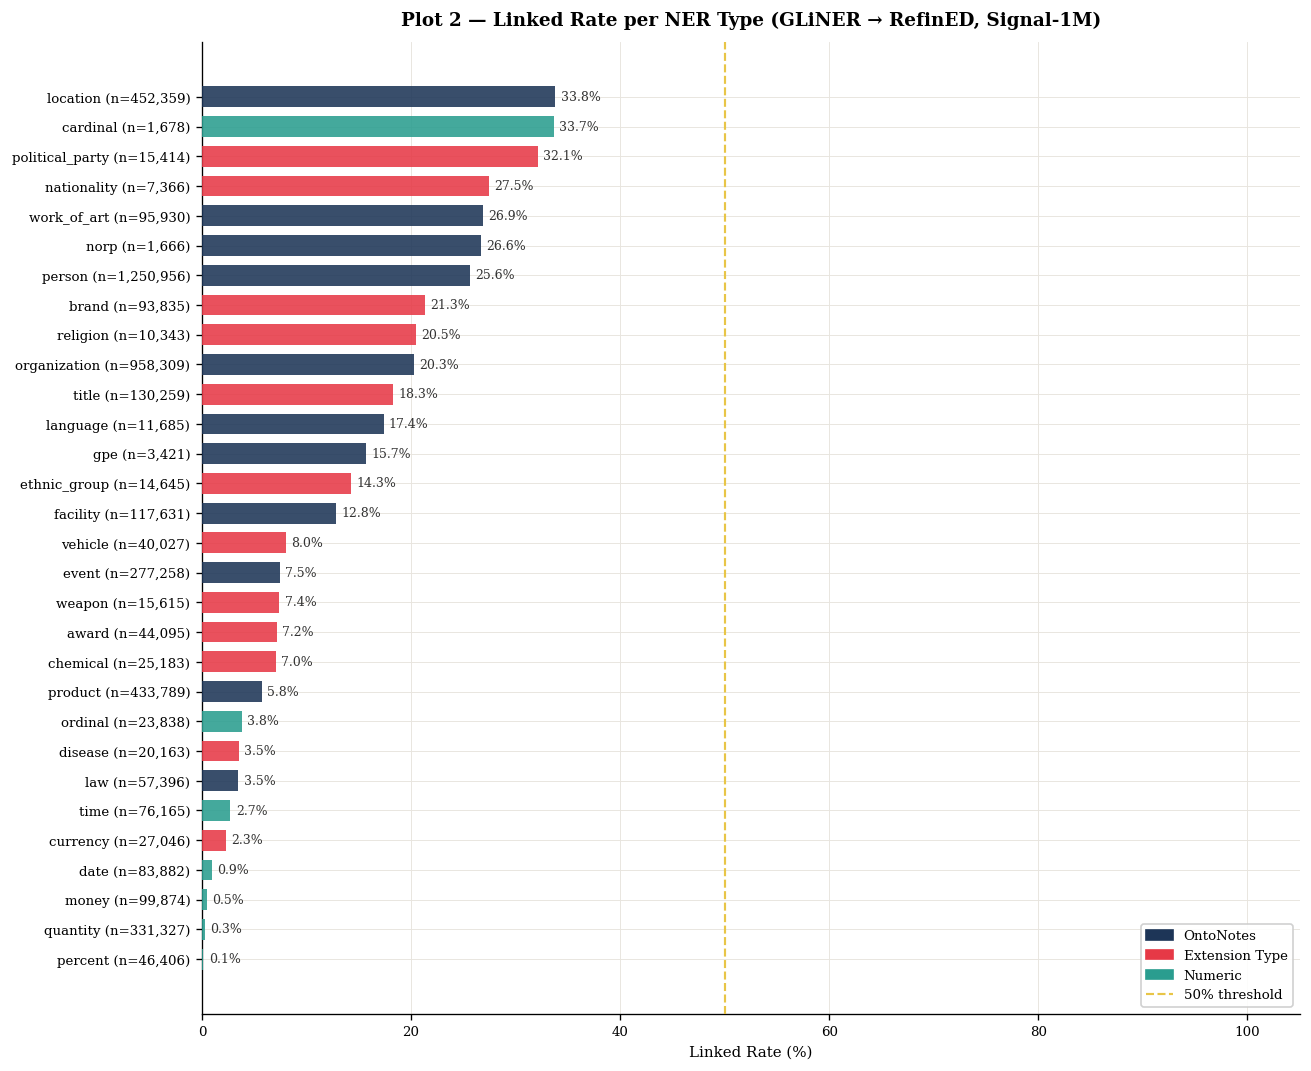

In [48]:
# ── Plotting Linked Rate ──────────────────────────────────────────────────────
# Sort by "Linked" instead of "Unlinked" (ascending=True so highest is at the top of the chart)
sdf_linked = df.sort_values("Linked", ascending=True).copy()

# Combine the NER type and its Total count into a single string for the Y-axis labels
sdf_linked["ner_label"] = sdf_linked.apply(lambda row: f"{row['ner_type']} (n={row['Total']:,})", axis=1)

# Generate color list based on mapped categories
colors_linked = [CAT_COLORS.get(c, "#95a5a6") for c in sdf_linked["category"]]

# Figure setup
fig, ax = plt.subplots(figsize=(11, 9)) 

# Plot using the 'ner_label' column for the Y-axis and 'Linked' for the X-axis
bars = ax.barh(sdf_linked["ner_label"], sdf_linked["Linked"], color=colors_linked, alpha=0.88,
               height=0.7, zorder=3)

# Annotate value at the end of the bar
for bar, val in zip(bars, sdf_linked["Linked"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=7.5, color="#333")

# 50% threshold line for visual reference
ax.axvline(50, color=C_ACCENT, lw=1.3, ls="--", zorder=4, label="50% threshold")

ax.set_xlabel("Linked Rate (%)")
ax.set_xlim(0, 105) 
ax.set_title("Plot 2 — Linked Rate per NER Type (GLiNER → RefinED, Signal-1M)",
             fontweight="bold", pad=10)

# Create custom legend using the categories
active_categories_linked = [c for c in CAT_COLORS if c in sdf_linked["category"].unique()]
legend_handles_linked = [
    mpatches.Patch(color=CAT_COLORS[c], label=c) for c in active_categories_linked
] + [plt.Line2D([0],[0], color=C_ACCENT, ls="--", lw=1.3, label="50% threshold")]

ax.legend(handles=legend_handles_linked, loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.savefig("figures/plot2_linked_rate.pdf")
plt.show()

---
## Plot 2 · Stacked Bar — Linked / NIL / Unlinked per NER Type
*Direct replication of Esquivel et al. Table 1 — now with 30 fine-grained types.*

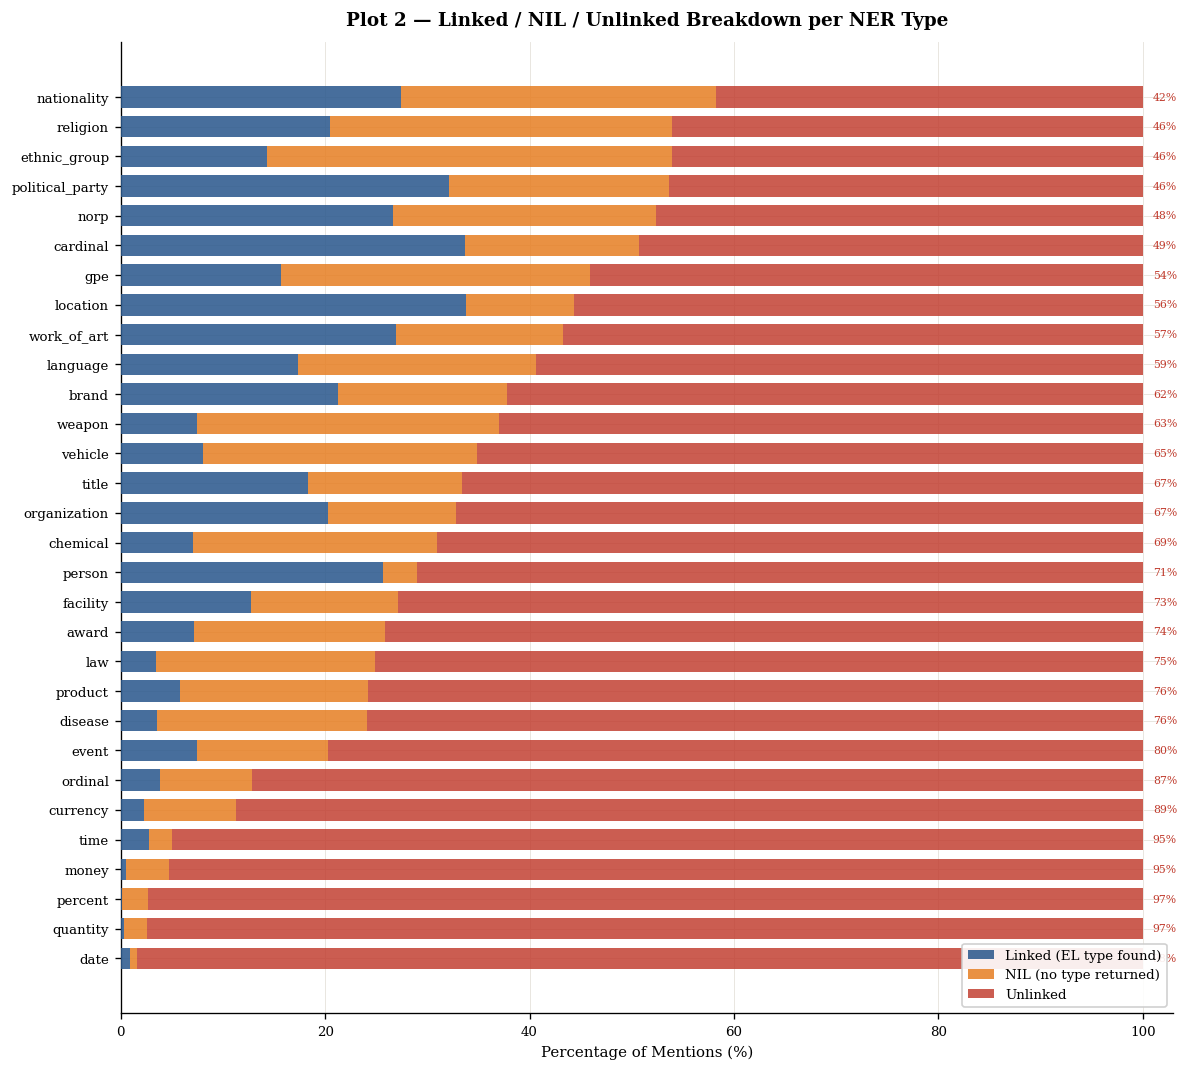

In [32]:
sdf = df.sort_values("Unlinked", ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
y = np.arange(len(sdf))

ax.barh(y, sdf["Linked"],   height=0.72, color=C_LINKED,   alpha=0.88,
        label="Linked (EL type found)", zorder=3)
ax.barh(y, sdf["NIL"],      height=0.72, left=sdf["Linked"],
        color=C_NIL, alpha=0.85, label="NIL (no type returned)", zorder=3)
ax.barh(y, sdf["Unlinked"], height=0.72,
        left=sdf["Linked"] + sdf["NIL"],
        color=C_UNLINKED, alpha=0.82, label="Unlinked", zorder=3)

ax.set_yticks(y); ax.set_yticklabels(sdf["ner_type"], fontsize=8)
ax.set_xlabel("Percentage of Mentions (%)")
ax.set_xlim(0, 103)
ax.set_title("Plot 2 — Linked / NIL / Unlinked Breakdown per NER Type",
             fontweight="bold", pad=10)
ax.legend(loc="lower right", framealpha=0.9)

# % Unlinked label
for i, (_, row) in enumerate(sdf.iterrows()):
    ax.text(101, i, f"{row['Unlinked']:.0f}%",
            va="center", ha="left", fontsize=6.5, color=C_UNLINKED)

plt.tight_layout()
plt.savefig("figures/plot2_stacked_linked_nil_unlinked.pdf")
plt.show()


---
## Plot 3 · Scatter — Total Mentions vs Unlinked Rate
*Do low-frequency types get linked less? The core long-tail argument.*

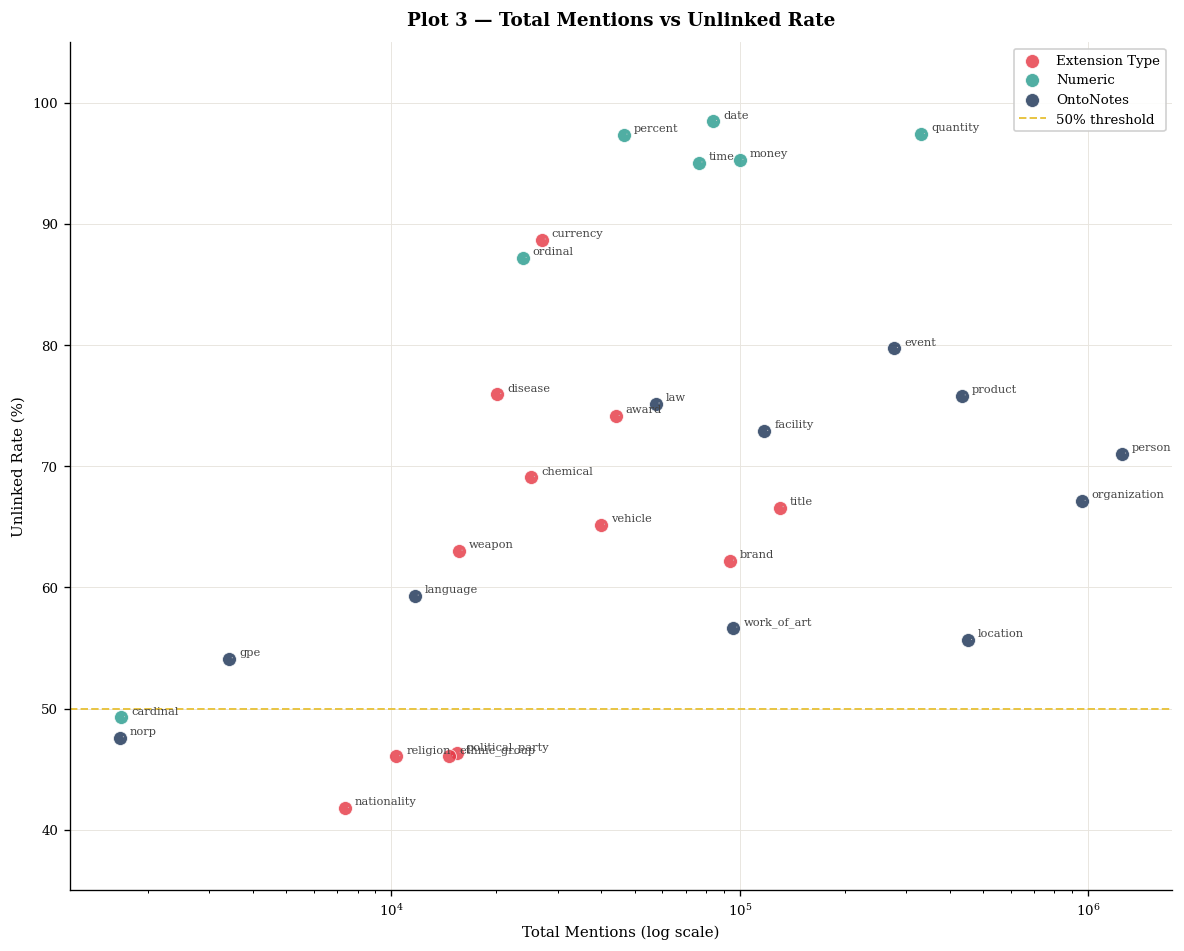

In [47]:
fig, ax = plt.subplots(figsize=(10, 8))

for cat, grp in df.groupby("category"):
    # Fixed size for uniform dot sizes
    ax.scatter(grp["Total"], grp["Unlinked"],
               s=70, 
               color=CAT_COLORS[cat], alpha=0.82,
               label=cat, zorder=3, edgecolors="white", linewidths=0.5)

# Labels for ALL types
for _, row in df.iterrows():
    # We removed the 'if' condition here so every row gets annotated
    ax.annotate(
        row["ner_type"],
        xy=(row["Total"], row["Unlinked"]),
        xytext=(6, 2), textcoords="offset points",
        fontsize=6.8, color="#444",
        # Kept the arrow styling in case points are close together
        arrowprops=dict(arrowstyle="-", color="#ccc", lw=0.6),
    )

ax.set_xscale("log")
ax.set_xlabel("Total Mentions (log scale)")
ax.set_ylabel("Unlinked Rate (%)")
ax.set_ylim(35, 105)
ax.axhline(50, color=C_ACCENT, lw=1.2, ls="--", label="50% threshold", zorder=2)

ax.set_title("Plot 3 — Total Mentions vs Unlinked Rate",
             fontweight="bold", pad=10)
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig("figures/plot3_scatter_total_vs_unlinked.pdf")
plt.show()

---
## Plot 4 · Heatmap — NER Type × EL Type
*Where do linked entities actually land in Wikipedia's type system?*

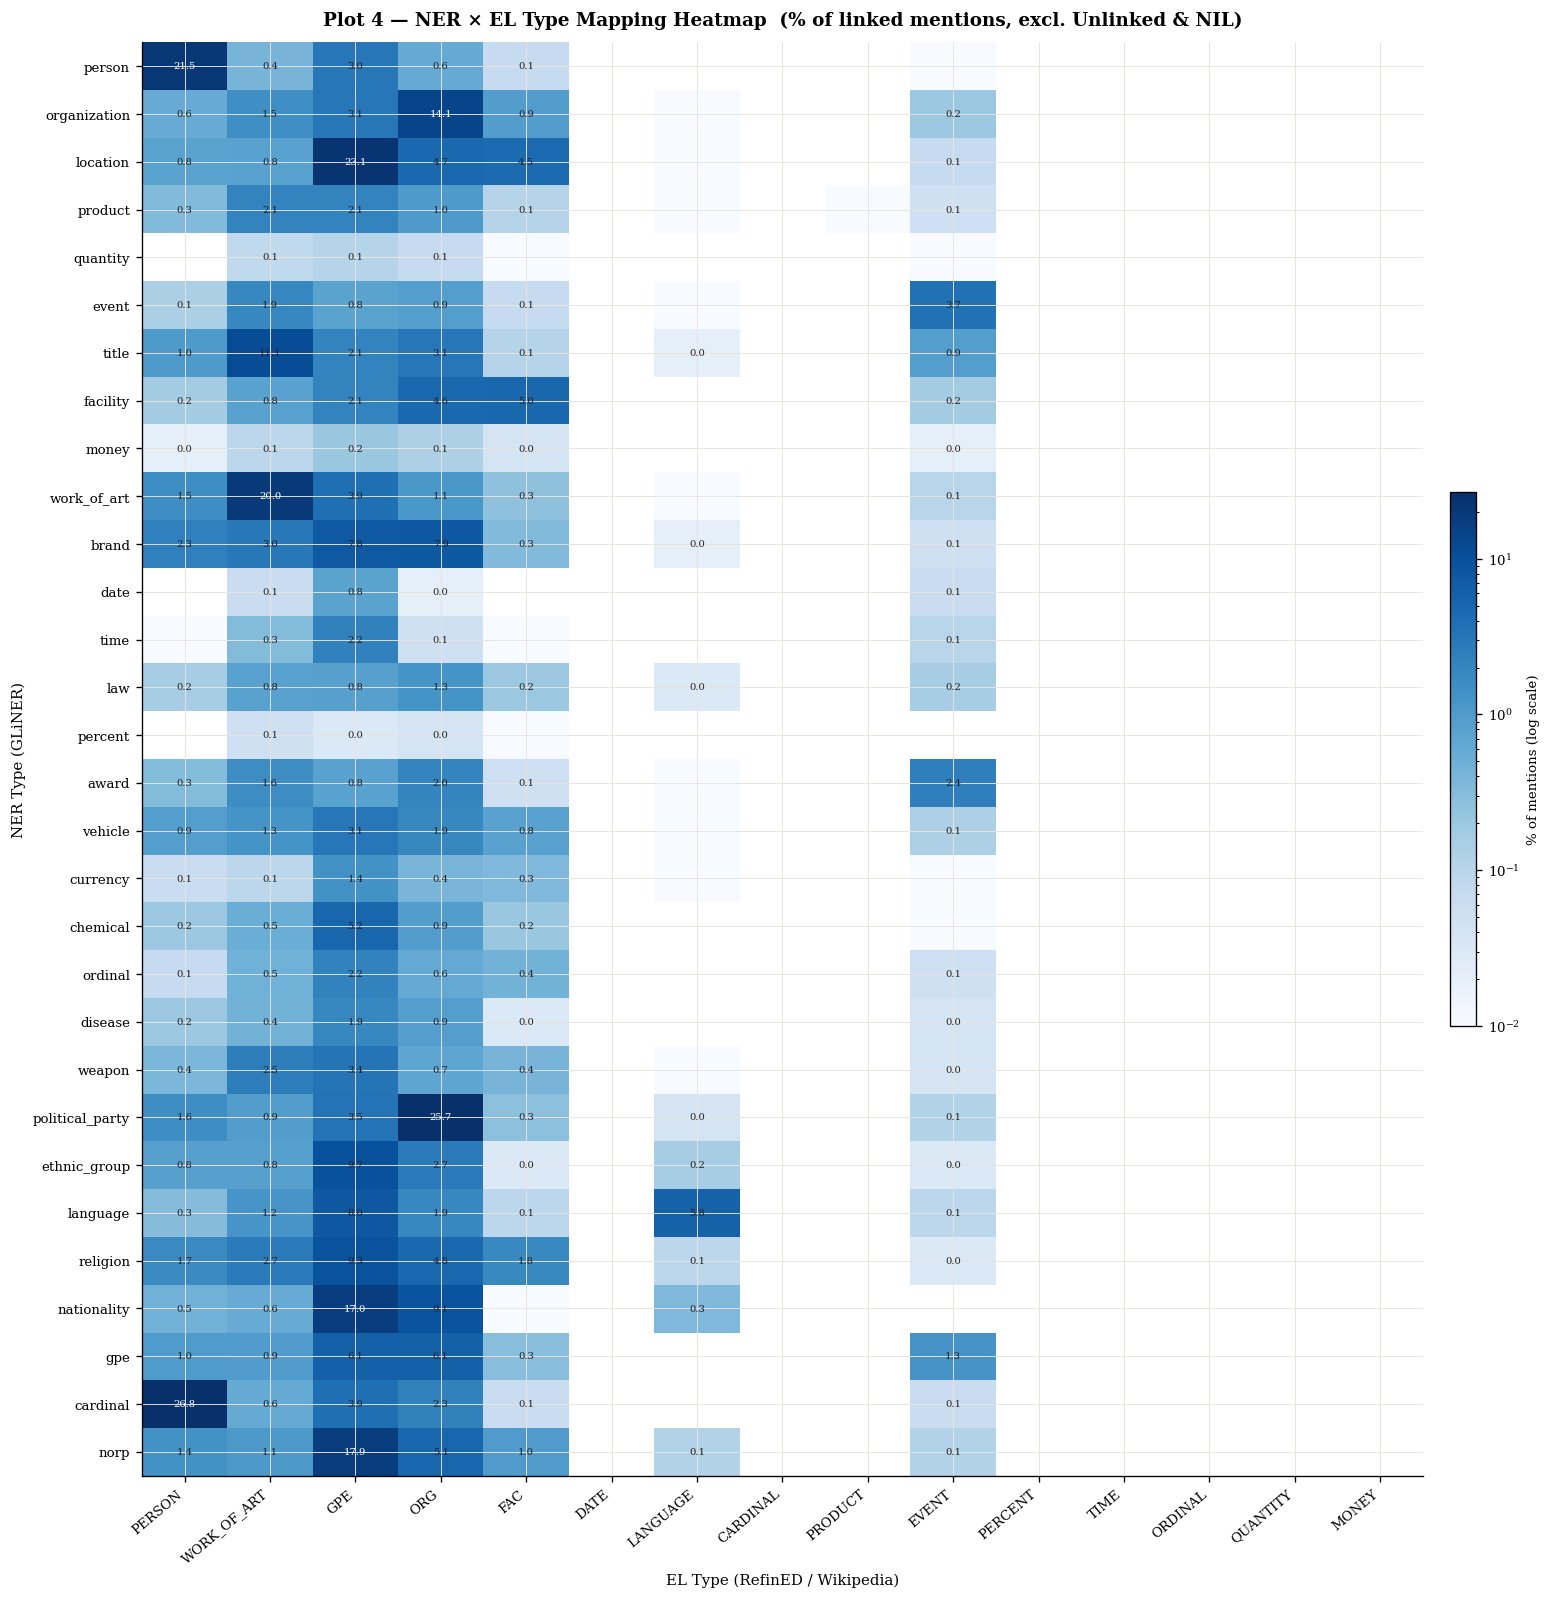

In [34]:
# Build matrix (rows = NER types sorted by Total desc, cols = EL types)
heat = df.set_index("ner_type")[EL_COLS].copy()
heat = heat.loc[df.sort_values("Total", ascending=False)["ner_type"]]

# Zero → NaN so they render white
vals   = heat.values.astype(float)
masked = np.where(vals == 0, np.nan, vals)

n_rows, n_cols = heat.shape
fig_h = max(7, n_rows * 0.38 + 2)

fig, ax = plt.subplots(figsize=(13, fig_h))
im = ax.imshow(masked, aspect="auto",
               cmap="Blues",
               norm=LogNorm(vmin=0.01, vmax=max(vals.max(), 1)))

ax.set_xticks(range(n_cols))
ax.set_xticklabels(heat.columns, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(n_rows))
ax.set_yticklabels(heat.index, fontsize=8)
ax.set_xlabel("EL Type (RefinED / Wikipedia)")
ax.set_ylabel("NER Type (GLiNER)")

# Annotate cells
vmax = vals.max() if vals.max() > 0 else 1
for i in range(n_rows):
    for j in range(n_cols):
        v = vals[i, j]
        if v > 0.01:
            ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                    fontsize=6,
                    color="white" if v > vmax * 0.45 else "#222")

cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02, shrink=0.8)
cbar.set_label("% of mentions (log scale)", fontsize=8)

ax.set_title("Plot 4 — NER × EL Type Mapping Heatmap  (% of linked mentions, excl. Unlinked & NIL)",
             fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("figures/plot4_heatmap_ner_x_el.pdf")
plt.show()


---
## Plot 5 · Grouped Bar — Top EL Types per NER Type
*Compact view of the dominant EL assignments for each NER type.*

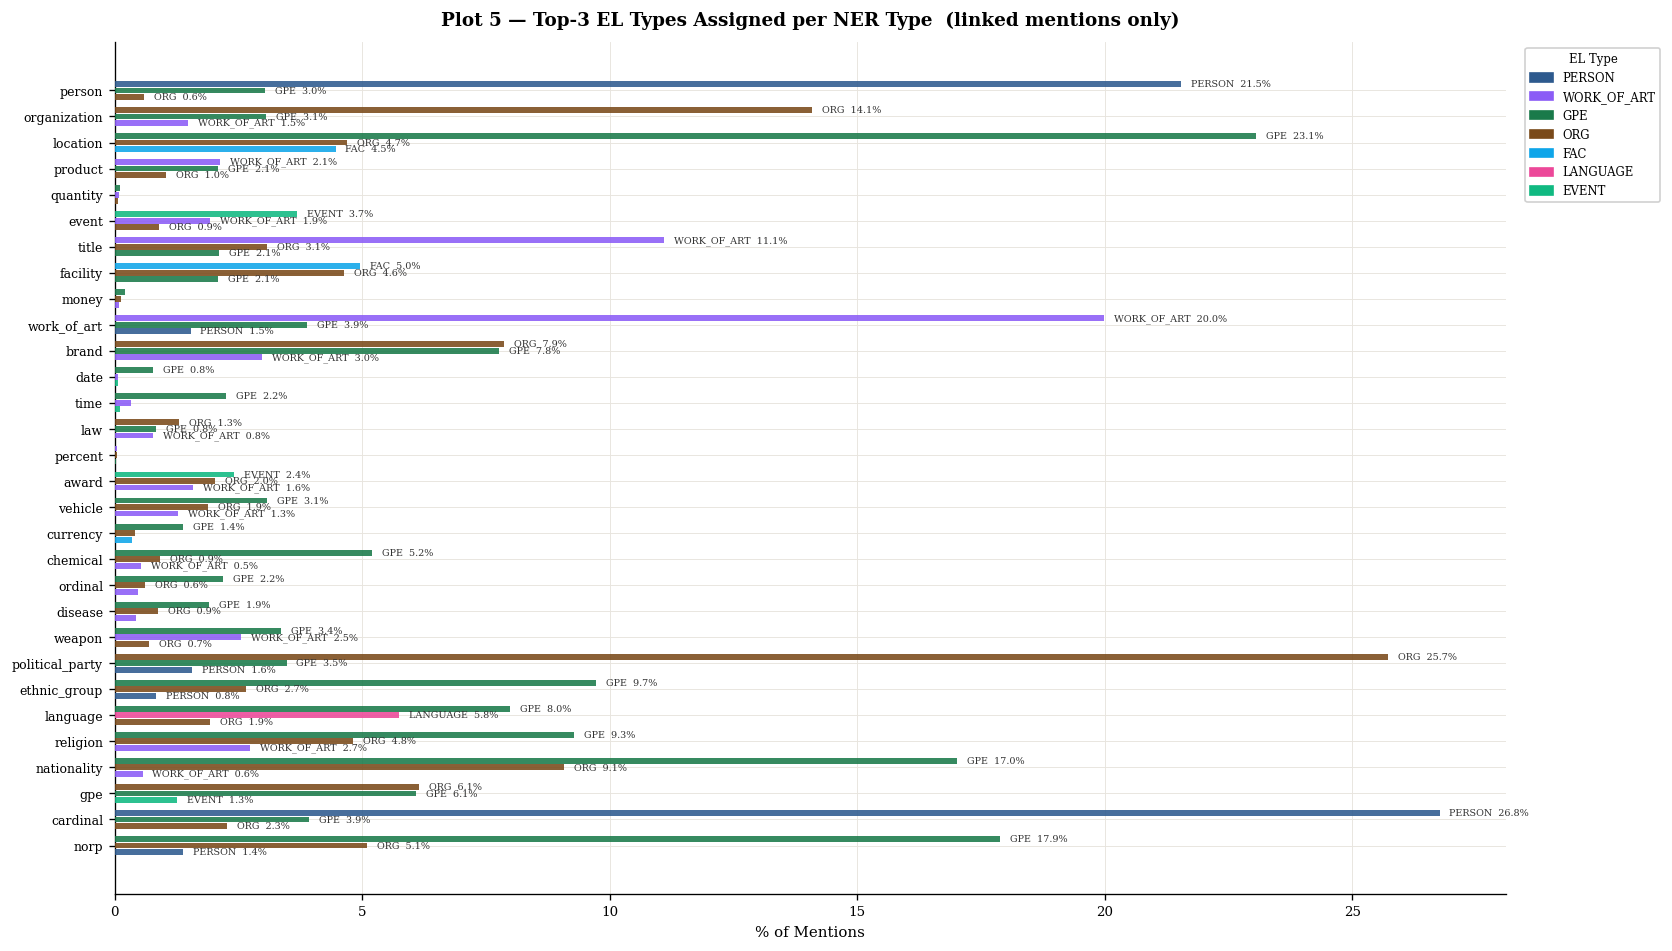

In [35]:
TOP_N = 3  # show top-N EL types per NER type

sdf   = df.sort_values("Total", ascending=False)
types = sdf["ner_type"].tolist()
n     = len(types)

# For each NER type, find top-N EL cols by value
records = []
for _, row in sdf.iterrows():
    el_vals = row[EL_COLS].sort_values(ascending=False).head(TOP_N)
    for rank, (el, pct) in enumerate(el_vals.items()):
        records.append({"ner_type": row["ner_type"], "el": el,
                        "pct": pct, "rank": rank, "total": row["Total"]})
top_df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(14, 8))
y_pos = {t: i for i, t in enumerate(types)}
bar_h = 0.25
offsets = [-bar_h, 0, bar_h]

for rank in range(TOP_N):
    sub = top_df[top_df["rank"] == rank]
    ys  = [y_pos[t] for t in sub["ner_type"]]
    cs  = [EL_COLOR_MAP.get(el, "#aaa") for el in sub["el"]]
    bars= ax.barh([y + offsets[rank] for y in ys],
                  sub["pct"].values, height=bar_h * 0.9,
                  color=cs, alpha=0.88, zorder=3,
                  label=f"#{rank+1} EL type")
    # label bars
    for bar, (_, row) in zip(bars, sub.iterrows()):
        if row["pct"] > 0.5:
            ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                    f"{row['el']}  {row['pct']:.1f}%",
                    va="center", fontsize=5.8, color="#333")

ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels(types, fontsize=7.5)
ax.set_xlabel("% of Mentions")
ax.set_title("Plot 5 — Top-3 EL Types Assigned per NER Type  (linked mentions only)",
             fontweight="bold", pad=10)
ax.invert_yaxis()

# EL colour legend
legend_handles = [mpatches.Patch(color=EL_COLOR_MAP[e], label=e)
                  for e in EL_COLS if e in top_df["el"].values]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left",
          fontsize=7, framealpha=0.9, title="EL Type", title_fontsize=7)
plt.tight_layout()
plt.savefig("figures/plot5_grouped_top_el_types.pdf")
plt.show()


---
## Plot 6 · Treemap — Total Mentions by NER Type
*The scale problem: `person` and `organization` dominate the corpus.*

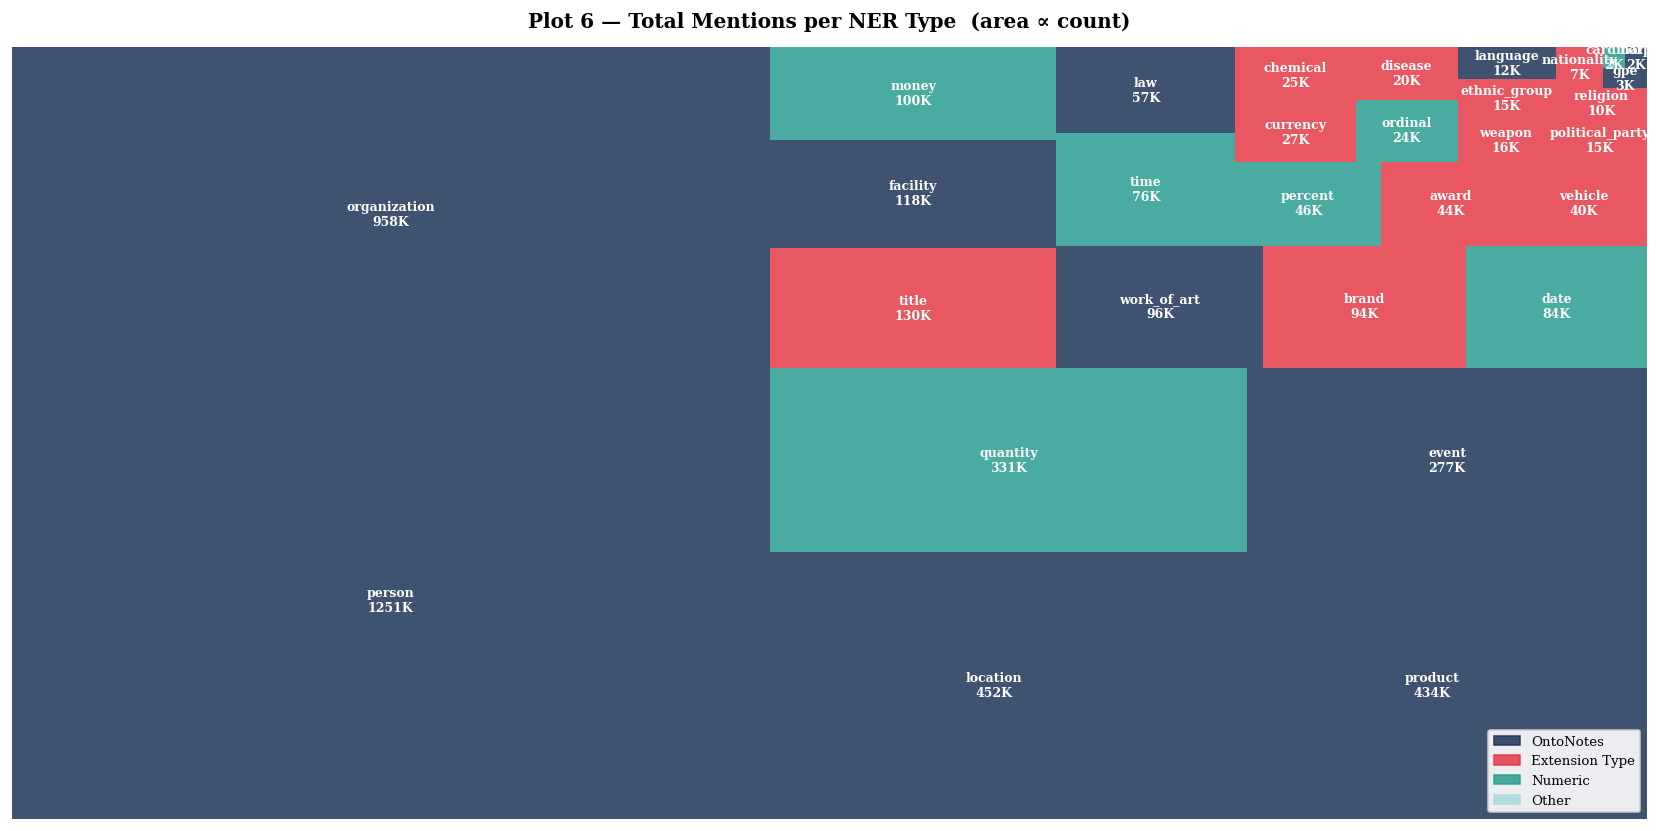

In [36]:
sdf  = df.sort_values("Total", ascending=False)
vals = sdf["Total"].values
labs = [f"{t}\n{v/1e3:.0f}K" for t, v in zip(sdf["ner_type"], vals)]
cols = [CAT_COLORS[c] for c in sdf["category"]]

# lighten small cells slightly
alpha_vals = [0.65 + 0.35 * (v / vals.max()) for v in vals]

fig, ax = plt.subplots(figsize=(14, 7))
squarify.plot(sizes=vals, label=labs, color=cols, alpha=0.85,
              text_kwargs={"fontsize": 7.5, "fontweight": "bold", "color": "white"},
              ax=ax)

ax.set_axis_off()
ax.set_title("Plot 6 — Total Mentions per NER Type  (area ∝ count)",
             fontweight="bold", pad=12, fontsize=12)

legend_handles = [mpatches.Patch(color=CAT_COLORS[c], alpha=0.85, label=c)
                  for c in CAT_COLORS]
ax.legend(handles=legend_handles, loc="lower right",
          framealpha=0.9, fontsize=8)
plt.tight_layout()
plt.savefig("figures/plot6_treemap_total_mentions.pdf")
plt.show()


---
## Plot 7 · 100% Stacked Bar — EL Type Breakdown (Linked Only)
*Strip out Unlinked & NIL — how do the linked mentions distribute across EL types?*

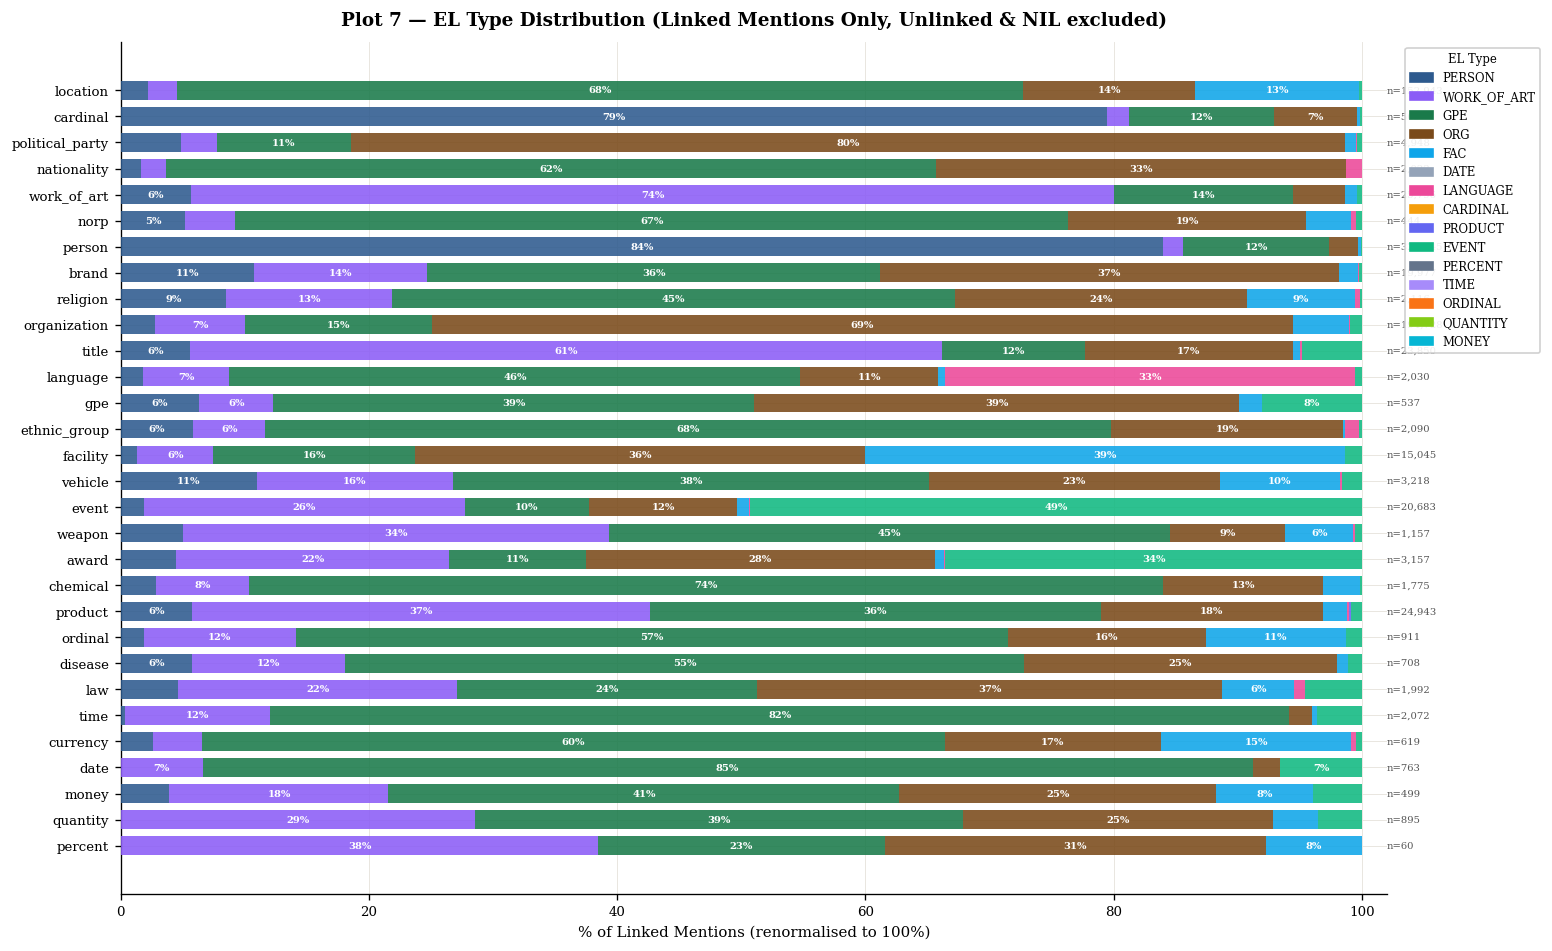

In [37]:
sdf    = df.sort_values("Linked", ascending=False)
el_mat = sdf[EL_COLS].copy()

# Renormalise rows to 100% of linked-only
row_sum = el_mat.sum(axis=1).replace(0, np.nan)
el_pct  = el_mat.div(row_sum, axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 8))
y   = np.arange(len(sdf))
left = np.zeros(len(sdf))

for col in EL_COLS:
    vals = el_pct[col].fillna(0).values
    bars = ax.barh(y, vals, left=left, height=0.72,
                   color=EL_COLOR_MAP[col], alpha=0.88, zorder=3, label=col)
    # label segments > 5%
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 5:
            ax.text(l + v/2, i, f"{v:.0f}%", ha="center", va="center",
                    fontsize=6, color="white", fontweight="bold")
    left = left + vals

ax.set_yticks(y)
ax.set_yticklabels(sdf["ner_type"], fontsize=8)
ax.set_xlim(0, 102)
ax.set_xlabel("% of Linked Mentions (renormalised to 100%)")
ax.set_title("Plot 7 — EL Type Distribution (Linked Mentions Only, Unlinked & NIL excluded)",
             fontweight="bold", pad=10)

# Show total linked count on right
for i, (_, row) in enumerate(sdf.iterrows()):
    ax.text(102, i, f"n={row['linked_count']:,}",
            va="center", fontsize=6, color="#555")

legend_handles = [mpatches.Patch(color=EL_COLOR_MAP[e], label=e) for e in EL_COLS]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left",
          fontsize=7, framealpha=0.9, title="EL Type", title_fontsize=7)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("figures/plot7_el_type_breakdown_linked_only.pdf")
plt.show()


---
## Plot 8 · Scatter — NIL Rate vs Unlinked Rate
*Two distinct failure modes — quadrant analysis.*

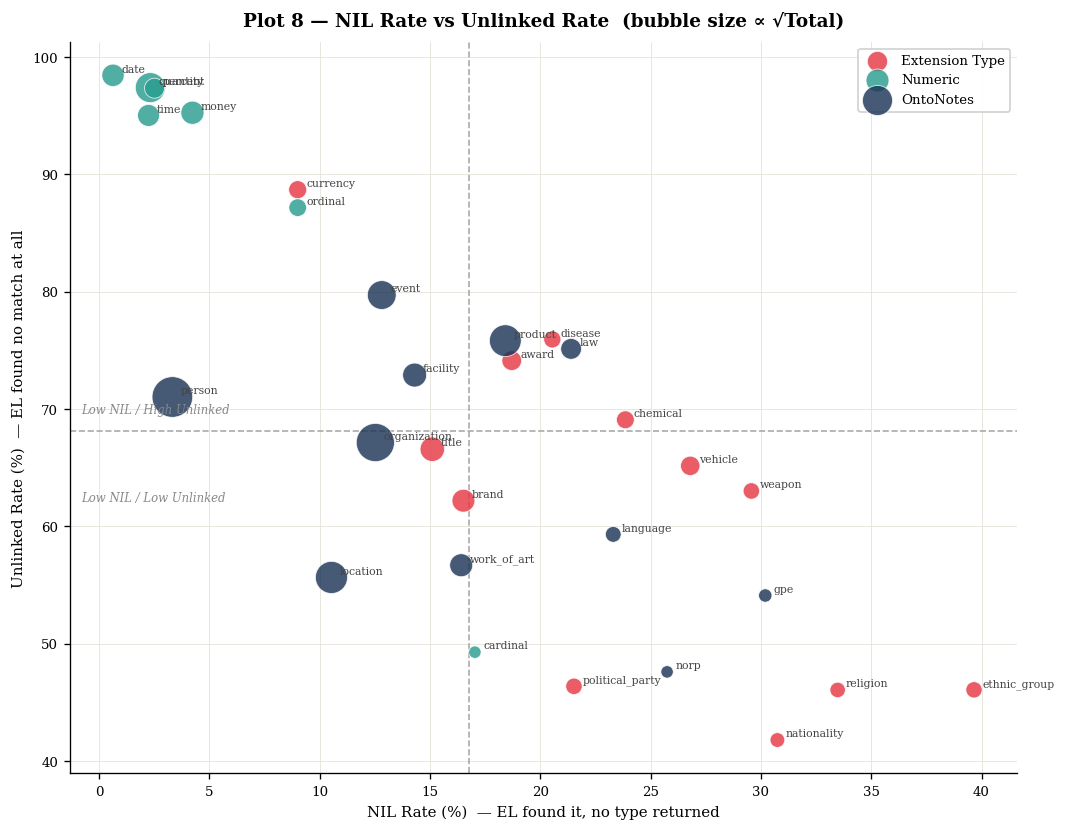

In [38]:
fig, ax = plt.subplots(figsize=(9, 7))

for cat, grp in df.groupby("category"):
    sc = ax.scatter(grp["NIL"], grp["Unlinked"],
                    s=np.sqrt(grp["Total"]) * 0.5 + 35,
                    color=CAT_COLORS[cat], alpha=0.82, label=cat,
                    zorder=3, edgecolors="white", linewidths=0.5)

for _, row in df.iterrows():
    ax.annotate(row["ner_type"],
                xy=(row["NIL"], row["Unlinked"]),
                xytext=(5, 2), textcoords="offset points",
                fontsize=6.5, color="#444")

# Quadrant lines — median
med_nil = df["NIL"].median()
med_unl = df["Unlinked"].median()
ax.axvline(med_nil, color="#aaa", lw=1, ls="--", zorder=2)
ax.axhline(med_unl, color="#aaa", lw=1, ls="--", zorder=2)

# Quadrant labels
pad = 0.5
ax.text(ax.get_xlim()[0]+pad, med_unl+1.5,  "Low NIL / High Unlinked", fontsize=7, color="#888", style="italic")
ax.text(ax.get_xlim()[0]+pad, med_unl-6,    "Low NIL / Low Unlinked",  fontsize=7, color="#888", style="italic")

ax.set_xlabel("NIL Rate (%)  — EL found it, no type returned")
ax.set_ylabel("Unlinked Rate (%)  — EL found no match at all")
ax.set_title("Plot 8 — NIL Rate vs Unlinked Rate  (bubble size ∝ √Total)",
             fontweight="bold", pad=10)
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig("figures/plot8_nil_vs_unlinked_scatter.pdf")
plt.show()


---
## Plot 9 · Lollipop — Expected vs Actual EL Type Match
*How well does RefinED's EL type align with what GLiNER labelled?  
Each lollipop shows the % that mapped to the "intuitively correct" EL type.*

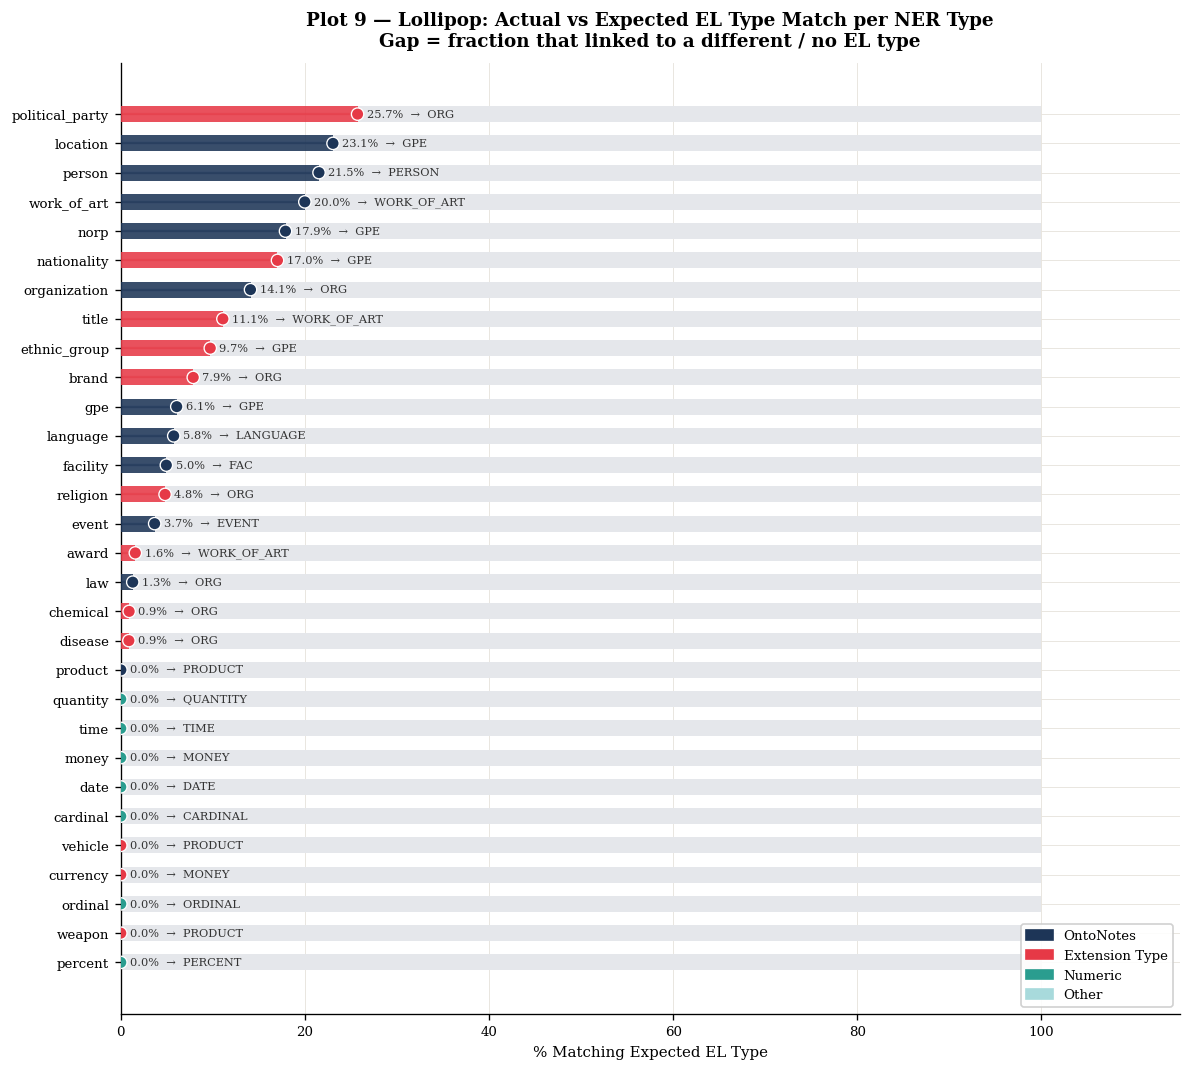

In [39]:
# For each NER type, define the "expected" EL type it should mostly link to
EXPECTED_EL = {
    "person":         "PERSON",
    "organization":   "ORG",
    "location":       "GPE",
    "gpe":            "GPE",
    "facility":       "FAC",
    "political_party":"ORG",
    "nationality":    "GPE",
    "ethnic_group":   "GPE",
    "norp":           "GPE",
    "religion":       "ORG",
    "product":        "PRODUCT",
    "event":          "EVENT",
    "work_of_art":    "WORK_OF_ART",
    "law":            "ORG",
    "title":          "WORK_OF_ART",
    "award":          "WORK_OF_ART",
    "disease":        "ORG",
    "chemical":       "ORG",
    "weapon":         "PRODUCT",
    "vehicle":        "PRODUCT",
    "brand":          "ORG",
    "language":       "LANGUAGE",
    "date":           "DATE",
    "time":           "TIME",
    "percent":        "PERCENT",
    "money":          "MONEY",
    "quantity":       "QUANTITY",
    "ordinal":        "ORDINAL",
    "cardinal":       "CARDINAL",
    "currency":       "MONEY",
}

rows = []
for _, row in df.iterrows():
    t   = row["ner_type"]
    exp = EXPECTED_EL.get(t)
    pct = row[exp] if exp and exp in row.index else 0.0
    rows.append({"ner_type": t, "expected_el": exp or "—",
                 "match_pct": pct, "total": row["Total"],
                 "category": row["category"]})
ldf = pd.DataFrame(rows).sort_values("match_pct", ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
y      = np.arange(len(ldf))
colors = [CAT_COLORS[c] for c in ldf["category"]]

# Gap bar (grey, from match_pct → 100, excluding Unlinked+NIL)
ax.barh(y, 100 - ldf["match_pct"], left=ldf["match_pct"],
        height=0.55, color="#e5e7eb", zorder=2)

# Match bar
ax.barh(y, ldf["match_pct"], height=0.55,
        color=colors, alpha=0.88, zorder=3)

# Lollipop stem + head
ax.hlines(y, 0, ldf["match_pct"], color=colors, alpha=0.5,
          linewidth=1.4, zorder=2)
ax.scatter(ldf["match_pct"], y, color=colors, s=55, zorder=4,
           edgecolors="white", linewidths=0.8)

# Labels: value + expected EL type
for i, (_, row) in enumerate(ldf.iterrows()):
    ax.text(row["match_pct"] + 1, i,
            f"{row['match_pct']:.1f}%  →  {row['expected_el']}",
            va="center", fontsize=6.8, color="#333")

ax.set_yticks(y)
ax.set_yticklabels(ldf["ner_type"], fontsize=8)
ax.set_xlim(0, 115)
ax.set_xlabel("% Matching Expected EL Type")
ax.set_title(
    "Plot 9 — Lollipop: Actual vs Expected EL Type Match per NER Type\n"
    "Gap = fraction that linked to a different / no EL type",
    fontweight="bold", pad=10)

legend_handles = [mpatches.Patch(color=CAT_COLORS[c], label=c) for c in CAT_COLORS]
ax.legend(handles=legend_handles, loc="lower right", framealpha=0.9)
plt.tight_layout()
plt.savefig("figures/plot9_lollipop_expected_vs_actual.pdf")
plt.show()


---
## Export Summary

In [40]:
import os
figs = [f for f in os.listdir("figures") if f.endswith(".pdf")]
print(f"Saved {len(figs)} figures to ./figures/:")
for f in sorted(figs):
    print(f"  {f}")


Saved 9 figures to ./figures/:
  plot1_unlinked_rate.pdf
  plot2_stacked_linked_nil_unlinked.pdf
  plot3_scatter_total_vs_unlinked.pdf
  plot4_heatmap_ner_x_el.pdf
  plot5_grouped_top_el_types.pdf
  plot6_treemap_total_mentions.pdf
  plot7_el_type_breakdown_linked_only.pdf
  plot8_nil_vs_unlinked_scatter.pdf
  plot9_lollipop_expected_vs_actual.pdf
